# Final Benchmark Comparison

All spectral identification methods compared: cosine (classical), DreaMS (pretrained), and spectral graph encoder V1/V2 (custom trained). Evaluated across noise levels and isomer difficulty.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_style("whitegrid")
sns.set_context("paper", font_scale=0.95)
plt.rcParams.update({
    "figure.figsize": (6, 2),
    "figure.dpi": 150,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "svg.fonttype": "none",
})

%matplotlib inline

## 1. Load Pre-computed Results

In [2]:
from pathlib import Path

classical = pd.read_parquet("../data/benchmark_classical.parquet")
dreams = pd.read_parquet("../data/benchmark_dreams.parquet")
custom = pd.read_parquet("../data/benchmark_custom_encoder.parquet")

# Load V2 if available
v2_path = Path("../data/benchmark_custom_encoder_v2.parquet")
custom_v2 = pd.read_parquet(v2_path) if v2_path.exists() else None

# Load reranker if available
reranker_path = Path("../data/benchmark_reranker_v3.parquet")
reranker = pd.read_parquet(reranker_path) if reranker_path.exists() else None

cosine_df = classical[classical["method"] == "cosine"]
results = pd.concat([cosine_df, dreams, custom], ignore_index=True)
if custom_v2 is not None:
    results = pd.concat([results, custom_v2], ignore_index=True)
if reranker is not None:
    results = pd.concat([results, reranker], ignore_index=True)

METHOD_LABELS = {
    "cosine": "Cosine (classical)",
    "dreams_s2s": "DreaMS (pretrained)",
    "custom_graph": "Spectral Graph V1",
    "custom_graph_v2": "Spectral Graph V2",
    "reranker_v3": "Reranker (DreaMS cross-attn)",
}
METHOD_COLORS = {
    "cosine": "#1f77b4",
    "dreams_s2s": "#ff7f0e",
    "custom_graph": "#2ca02c",
    "custom_graph_v2": "#9467bd",
    "reranker_v3": "#d62728",
}
METHODS = ["cosine", "dreams_s2s", "custom_graph"]
if custom_v2 is not None:
    METHODS.append("custom_graph_v2")
if reranker is not None:
    METHODS.append("reranker_v3")
NOISE_ORDER = ["clean", "mild", "moderate", "severe", "extreme"]
SET_ORDER = ["0% isomer", "50% isomer", "100% isomer"]

print(f"Classical: {len(classical)} rows ({classical['method'].nunique()} methods)")
print(f"DreaMS:    {len(dreams)} rows")
print(f"Custom V1: {len(custom)} rows")
if custom_v2 is not None:
    print(f"Custom V2: {len(custom_v2)} rows")
if reranker is not None:
    print(f"Reranker:  {len(reranker)} rows")
print(f"Combined:  {len(results)} rows")
print()
print(results[["eval_set", "method", "noise", "top_1", "class_top_1", "mrr"]].to_string(index=False))

Classical: 75 rows (5 methods)
DreaMS:    15 rows
Custom V1: 15 rows
Custom V2: 15 rows
Reranker:  15 rows
Combined:  75 rows

   eval_set          method    noise  top_1  class_top_1      mrr
  0% isomer          cosine    clean   1.00         1.00 1.000000
  0% isomer          cosine     mild   0.99         0.99 0.995000
  0% isomer          cosine moderate   0.96         0.98 0.973333
  0% isomer          cosine   severe   0.79         0.84 0.840500
  0% isomer          cosine  extreme   0.43         0.59 0.553552
 50% isomer          cosine    clean   0.70         1.00 0.819750
 50% isomer          cosine     mild   0.70         1.00 0.818500
 50% isomer          cosine moderate   0.65         0.96 0.762845
 50% isomer          cosine   severe   0.53         0.80 0.615940
 50% isomer          cosine  extreme   0.22         0.41 0.308401
100% isomer          cosine    clean   0.41         1.00 0.647083
100% isomer          cosine     mild   0.39         0.99 0.630417
100% isomer    

## 2. Summary Table

In [3]:
summary = results.groupby(["method", "noise"])[
    ["top_1", "top_5", "top_10", "class_top_1", "mrr", "mean_query_ms"]
].mean().reset_index()
summary["method"] = summary["method"].map(METHOD_LABELS)
noise_cat = pd.Categorical(summary["noise"], categories=NOISE_ORDER, ordered=True)
summary = summary.assign(noise=noise_cat).sort_values(["method", "noise"]).reset_index(drop=True)
print(summary.to_string(index=False, float_format="{:.3f}".format))

                      method    noise  top_1  top_5  top_10  class_top_1   mrr  mean_query_ms
          Cosine (classical)    clean  0.703  0.973   0.997        1.000 0.822         33.852
          Cosine (classical)     mild  0.693  0.973   0.993        0.993 0.815         29.731
          Cosine (classical) moderate  0.657  0.917   0.947        0.967 0.772         30.352
          Cosine (classical)   severe  0.510  0.743   0.823        0.797 0.611         30.234
          Cosine (classical)  extreme  0.230  0.450   0.527        0.480 0.328         30.194
         DreaMS (pretrained)    clean  0.703  0.977   1.000        1.000 0.829        627.762
         DreaMS (pretrained)     mild  0.617  0.877   0.923        0.937 0.734        627.762
         DreaMS (pretrained) moderate  0.420  0.673   0.793        0.830 0.538        627.762
         DreaMS (pretrained)   severe  0.267  0.520   0.633        0.613 0.378        627.762
         DreaMS (pretrained)  extreme  0.127  0.313   0.430 

## 3. Top-1 Accuracy vs Noise (faceted by eval set)

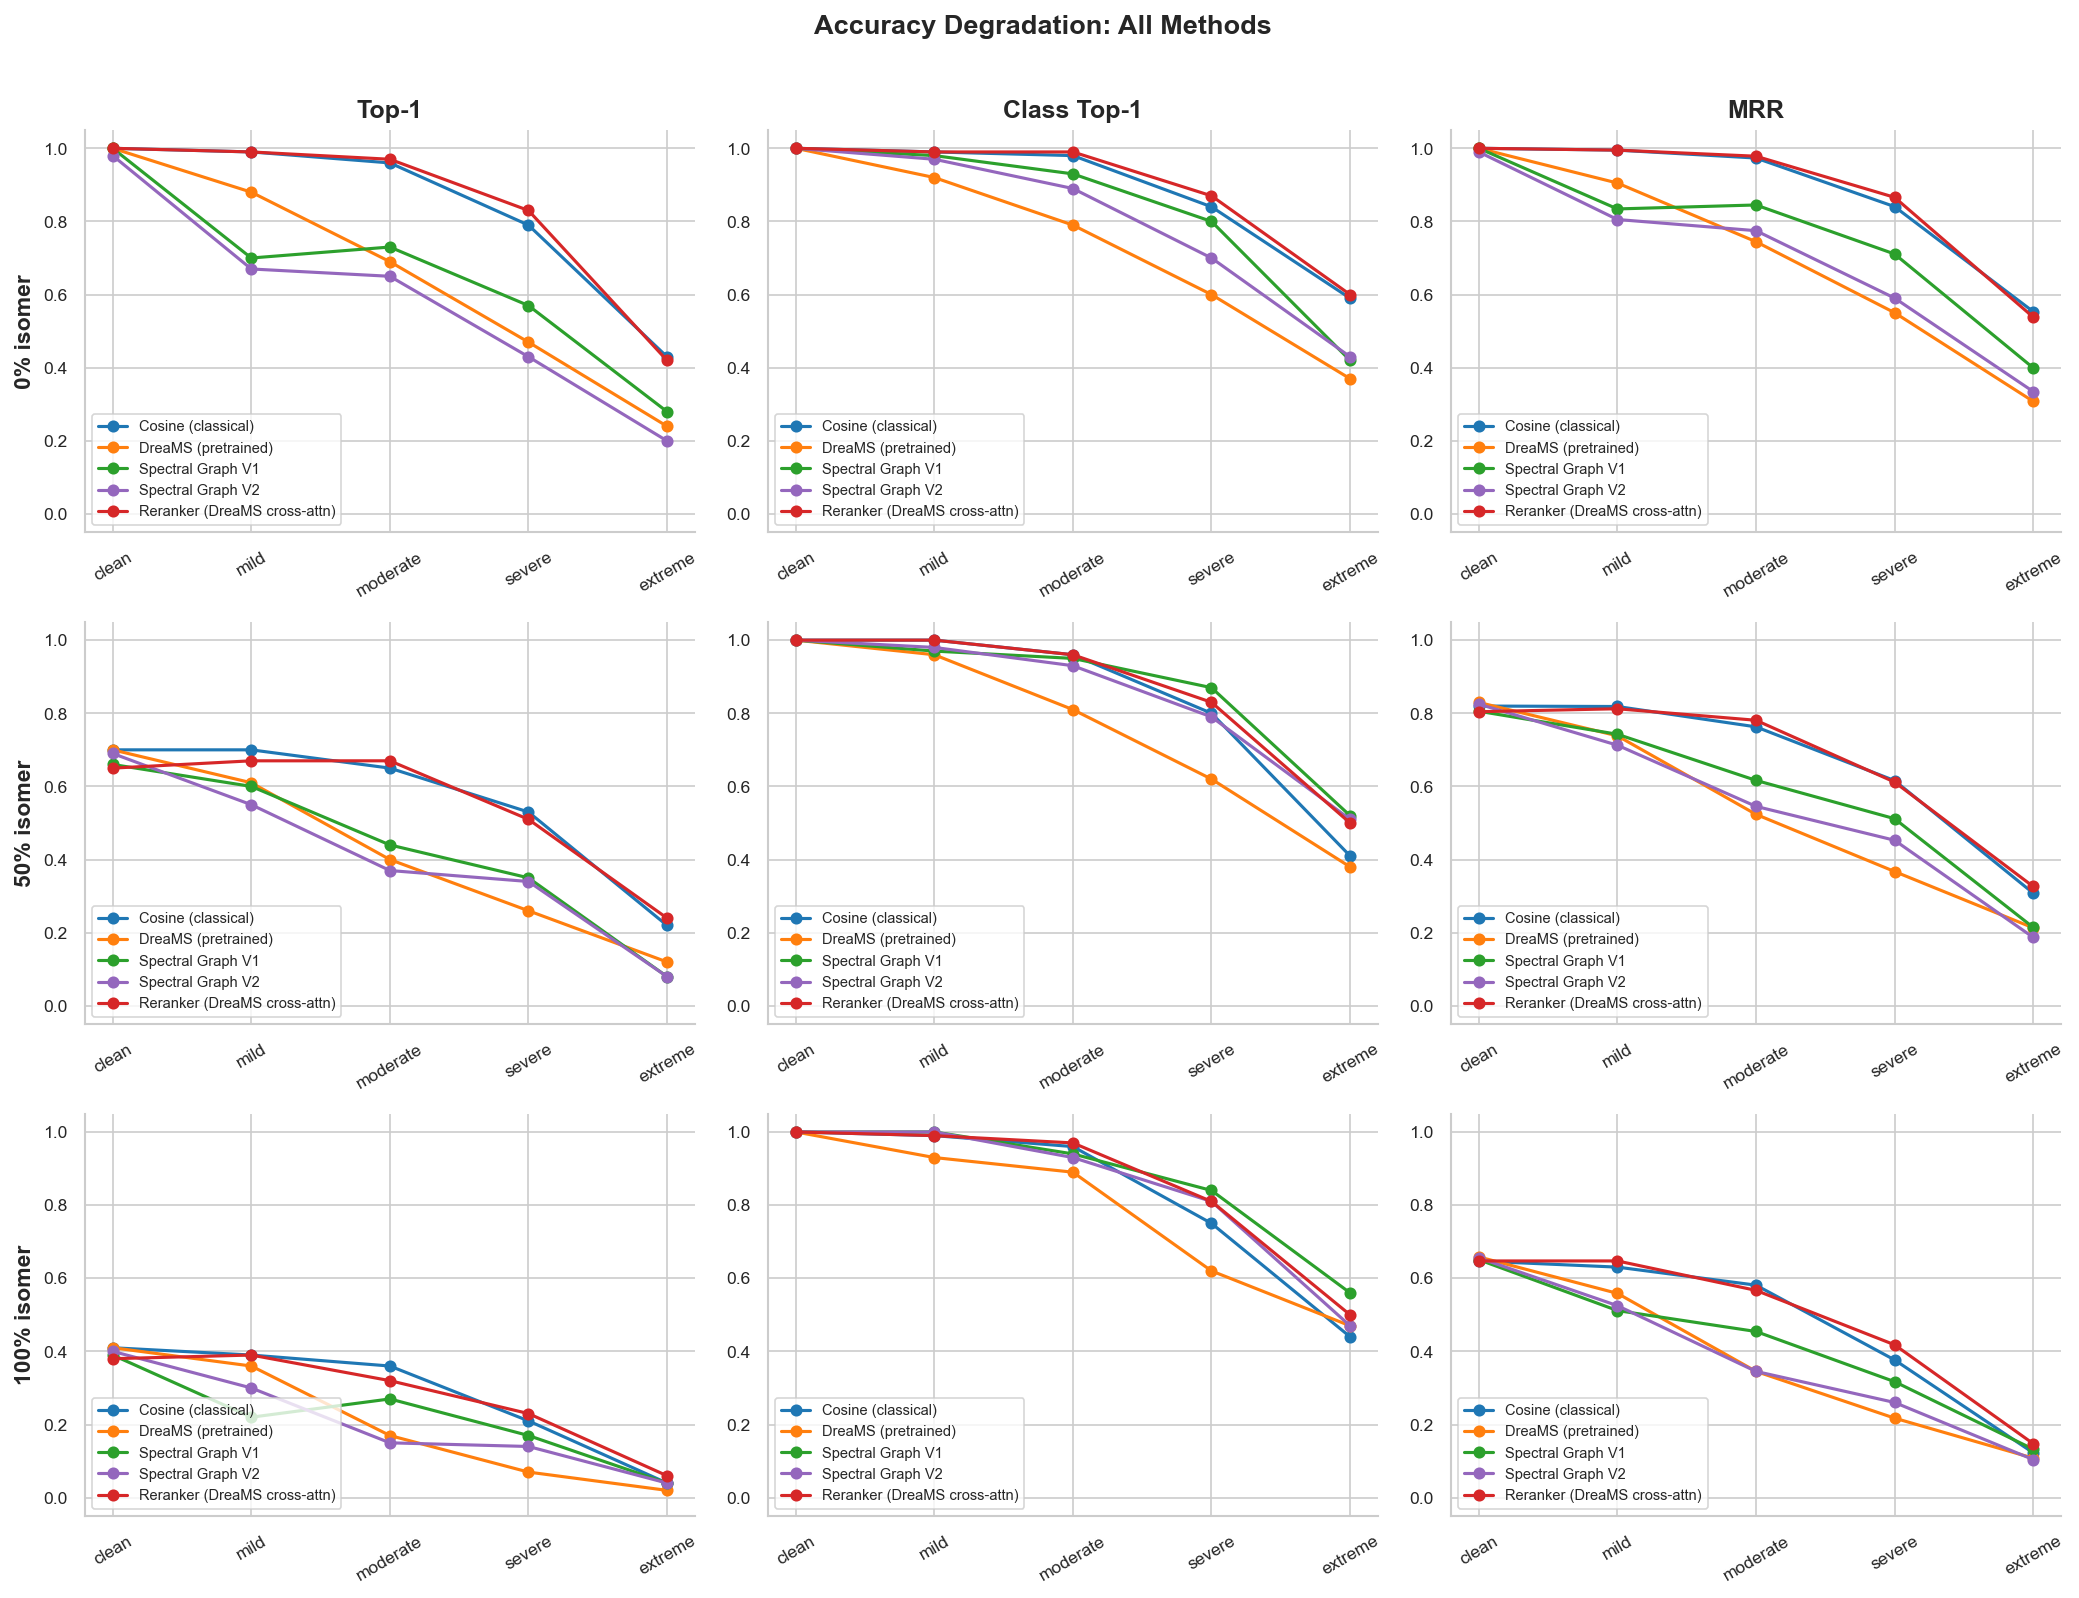

In [4]:
metrics = [("top_1", "Top-1"), ("class_top_1", "Class Top-1"), ("mrr", "MRR")]

fig, axes = plt.subplots(len(SET_ORDER), len(metrics), figsize=(14, 3.5 * len(SET_ORDER)))

for row, eval_set in enumerate(SET_ORDER):
    subset = results[results["eval_set"] == eval_set]
    for col, (metric, title) in enumerate(metrics):
        ax = axes[row, col]
        for method in METHODS:
            m = subset[subset["method"] == method]
            if len(m) == 0:
                continue
            m = m.copy()
            m["noise"] = pd.Categorical(m["noise"], categories=NOISE_ORDER, ordered=True)
            m = m.sort_values("noise")
            ax.plot(
                m["noise"].astype(str), m[metric], marker="o", linewidth=1.5,
                label=METHOD_LABELS.get(method, method),
                color=METHOD_COLORS.get(method, "gray"),
            )
        ax.set_ylim(-0.05, 1.05)
        ax.legend(fontsize=7, loc="lower left")
        if row == 0:
            ax.set_title(title, fontweight="bold")
        if col == 0:
            ax.set_ylabel(eval_set, fontweight="bold", fontsize=11)
        ax.tick_params(axis="x", rotation=30)

plt.suptitle("Accuracy Degradation: All Methods", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
fig.savefig("../figures/all_methods_noise_degradation.png", dpi=200, bbox_inches="tight")
plt.show()

## 4. Class-level Top-1 vs Noise

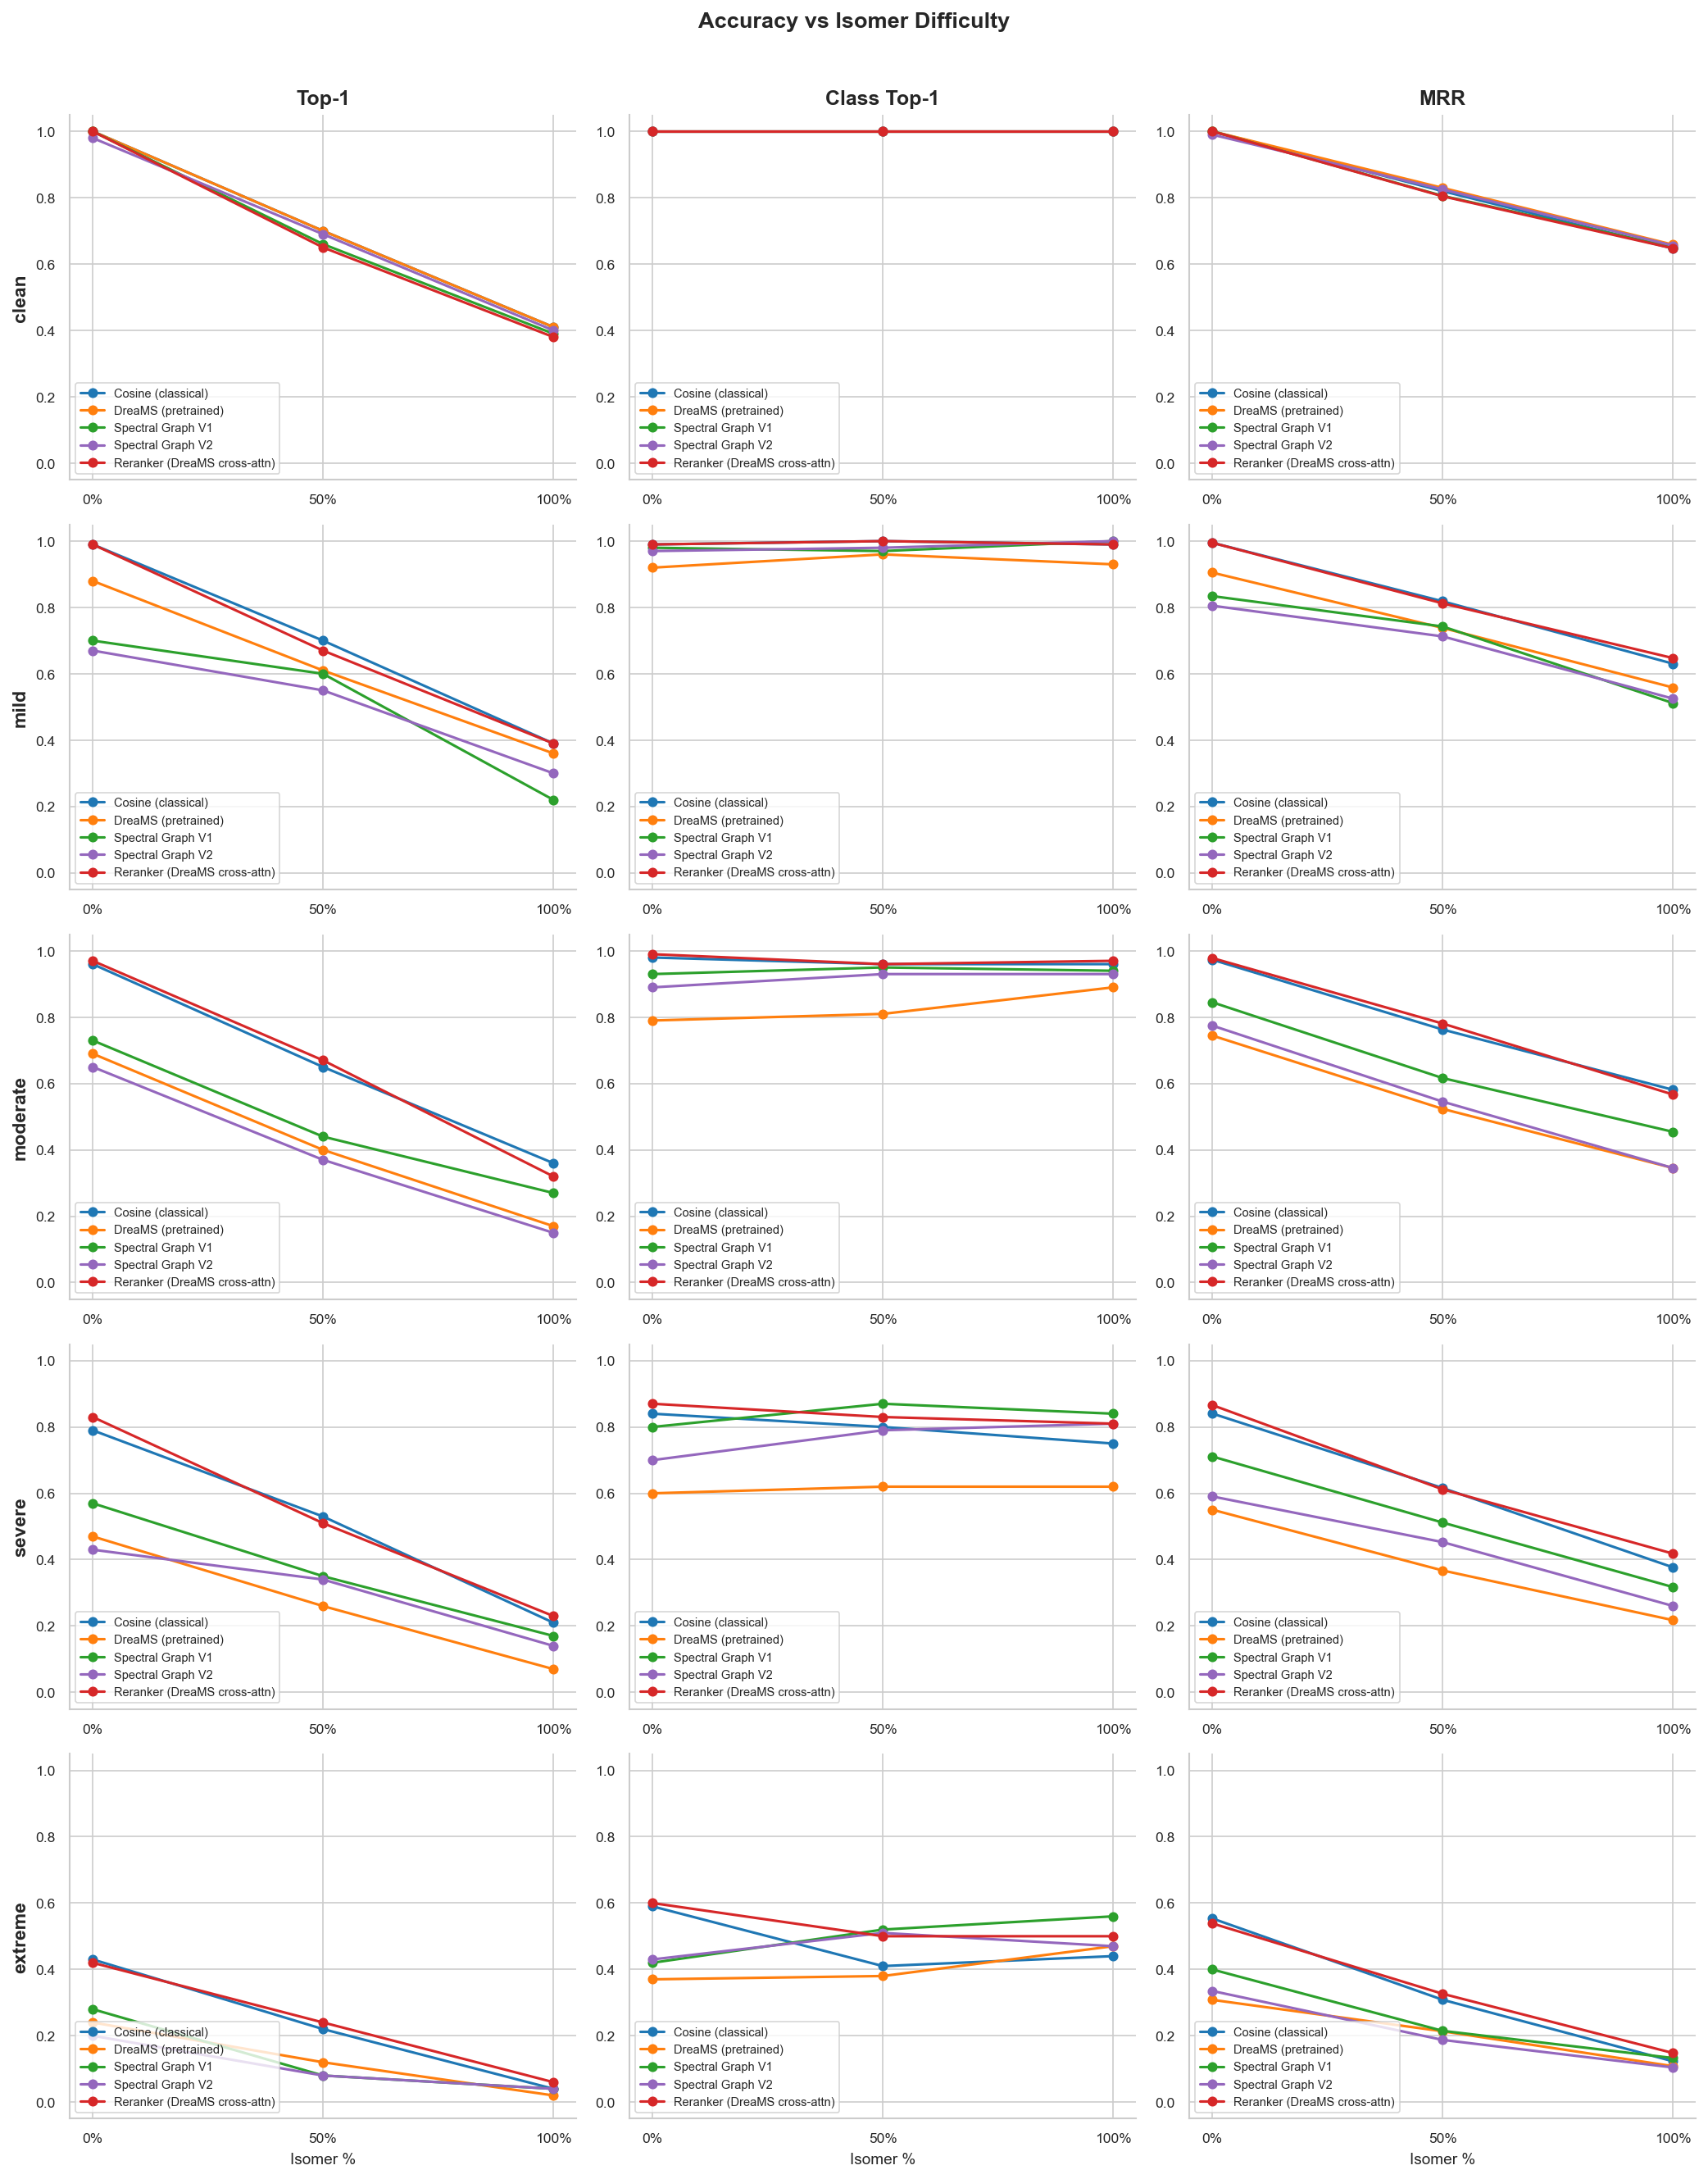

In [5]:
ISOMER_PCTS = [0, 50, 100]
set_to_pct = {"0% isomer": 0, "50% isomer": 50, "100% isomer": 100}
results["isomer_pct"] = results["eval_set"].map(set_to_pct)

fig, axes = plt.subplots(len(NOISE_ORDER), len(metrics), figsize=(14, 3.5 * len(NOISE_ORDER)))

for row, noise in enumerate(NOISE_ORDER):
    subset = results[results["noise"] == noise]
    for col, (metric, title) in enumerate(metrics):
        ax = axes[row, col]
        for method in METHODS:
            m = subset[subset["method"] == method]
            if len(m) == 0:
                continue
            m = m.copy().sort_values("isomer_pct")
            ax.plot(
                m["isomer_pct"], m[metric], marker="o", linewidth=1.5,
                label=METHOD_LABELS.get(method, method),
                color=METHOD_COLORS.get(method, "gray"),
            )
        ax.set_ylim(-0.05, 1.05)
        ax.set_xticks(ISOMER_PCTS)
        ax.set_xticklabels(["0%", "50%", "100%"])
        ax.legend(fontsize=7, loc="lower left")
        if row == 0:
            ax.set_title(title, fontweight="bold")
        if col == 0:
            ax.set_ylabel(noise, fontweight="bold", fontsize=11)
        if row == len(NOISE_ORDER) - 1:
            ax.set_xlabel("Isomer %")

plt.suptitle("Accuracy vs Isomer Difficulty", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 5. Delta Heatmap: Spectral Graph vs Cosine

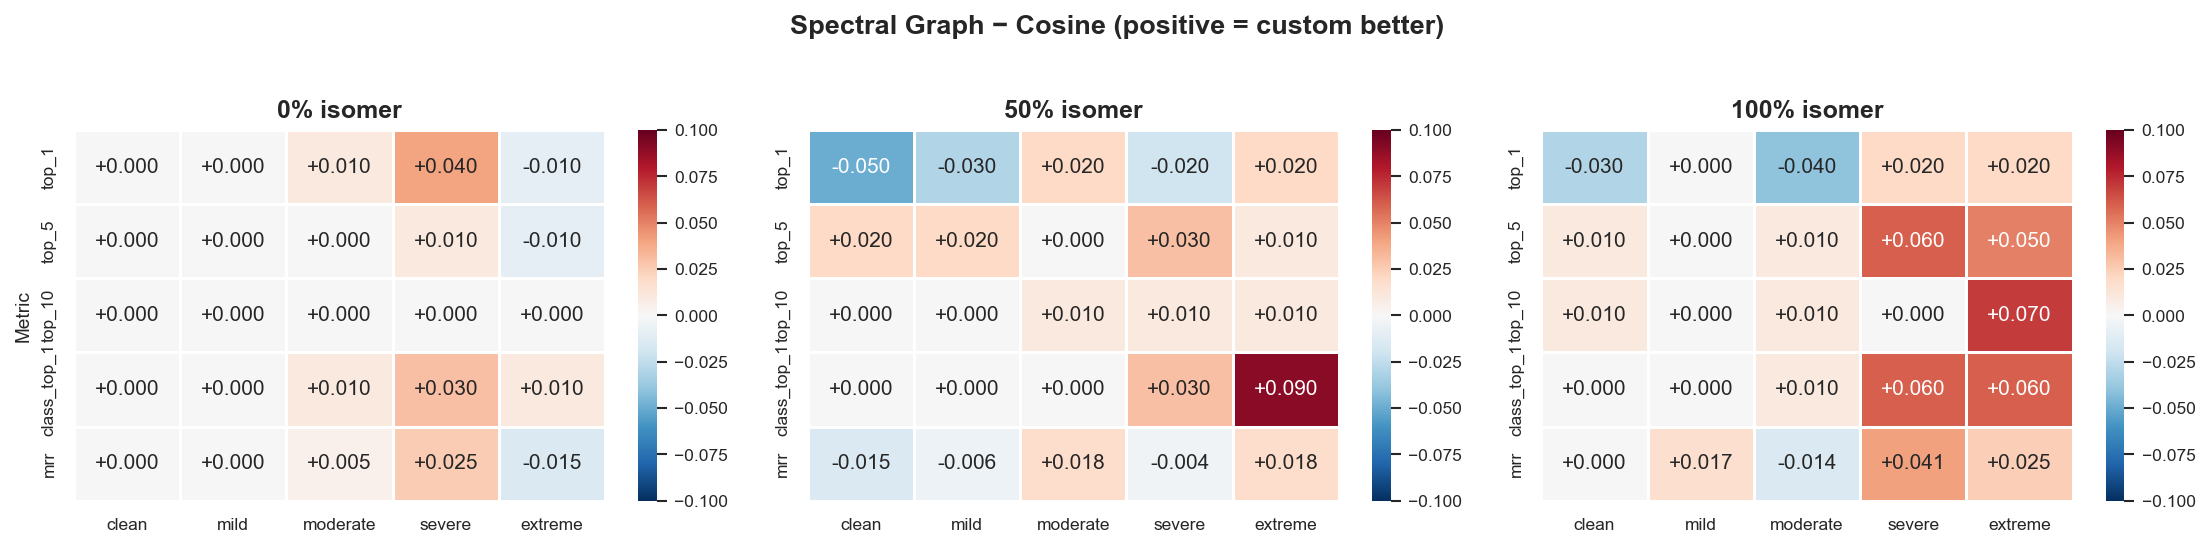

In [6]:
delta_rows = []
for eval_set in SET_ORDER:
    cos = results[(results["eval_set"] == eval_set) & (results["method"] == "cosine")].set_index("noise")
    best = results[(results["eval_set"] == eval_set) & (results["method"] == "reranker_v3")].set_index("noise")
    for noise in NOISE_ORDER:
        for metric in ["top_1", "top_5", "top_10", "class_top_1", "mrr"]:
            delta_rows.append({
                "eval_set": eval_set, "noise": noise, "metric": metric,
                "delta": best.loc[noise, metric] - cos.loc[noise, metric],
            })
delta = pd.DataFrame(delta_rows)

fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
for i, eval_set in enumerate(SET_ORDER):
    ax = axes[i]
    sub = delta[delta["eval_set"] == eval_set]
    pivot = sub.pivot(index="metric", columns="noise", values="delta")
    pivot = pivot.loc[["top_1", "top_5", "top_10", "class_top_1", "mrr"], NOISE_ORDER]
    vmax = max(0.1, abs(pivot.values).max())
    sns.heatmap(
        pivot, annot=True, fmt="+.3f", cmap="RdBu_r",
        center=0, vmin=-vmax, vmax=vmax, ax=ax,
        linewidths=0.5, linecolor="white",
    )
    ax.set_title(eval_set, fontweight="bold")
    ax.set_ylabel("" if i > 0 else "Metric")
    ax.set_xlabel("")

plt.suptitle("Spectral Graph \u2212 Cosine (positive = custom better)", fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

## 6. Query Time Comparison

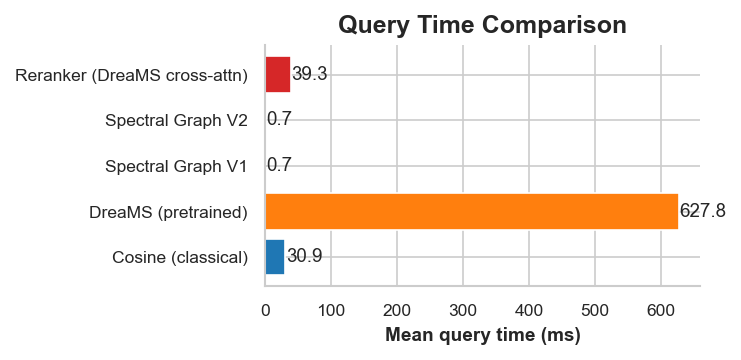

In [7]:
time_df = results.groupby("method")["mean_query_ms"].mean().reset_index()
time_df["label"] = time_df["method"].map(METHOD_LABELS)
time_df = time_df.set_index("method")
time_df = time_df.loc[[m for m in METHODS if m in time_df.index]].reset_index()

fig, ax = plt.subplots(figsize=(5, 2.5))
bars = ax.barh(time_df["label"], time_df["mean_query_ms"],
               color=[METHOD_COLORS.get(m, "gray") for m in time_df["method"]])
ax.set_xlabel("Mean query time (ms)", fontweight="bold")
for bar, val in zip(bars, time_df["mean_query_ms"]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}", va="center", fontsize=9)
ax.set_title("Query Time Comparison", fontweight="bold")
plt.tight_layout()
fig.savefig("../figures/query_time_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

## 7. Key Findings

**Performance ranking** (0% isomer, averaged across noise): Reranker > Cosine > Custom V1 > Custom V2 > DreaMS

**Why the reranker wins:**
- Cross-attention compares query and candidate peaks directly — the same late-interaction advantage cosine has, but with learned attention weights and DreaMS spectral embeddings providing richer features
- On 0% isomer, the reranker matches or exceeds cosine at all noise levels

**Why bi-encoder approaches underperform cosine on LipidBlast:**
- Both V1 and V2 embed each spectrum into a single vector before comparison
- With only ~5 peaks per spectrum and categorical intensities, the bi-encoder bottleneck destroys the fine-grained peak-position information that late-interaction methods preserve

**What the encoders do well:**
- 50-1000x faster than cosine per query (0.7ms vs 30ms)
- Class-level accuracy near 1.0 on clean queries — captures lipid class structure
- Isomer sets are information-theoretically unsolvable: spectrally identical isomers share the same inputs